In [1]:
!pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 795.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: requ

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchattacks

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 70.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 35.4MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 65.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.81MB/s]


In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Conv2d(1, 16, 3)
        self.fc = nn.Linear(26*26*16, 10)

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN()

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Training complete")

Training complete


In [6]:
attack = torchattacks.FGSM(model, eps=0.3)

for images, labels in test_loader:
    adv_images = attack(images, labels)
    outputs = model(adv_images)
    break

In [7]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy on normal images:", 100 * correct / total)

Accuracy on normal images: 97.87


In [8]:
correct = 0
total = 0

for images, labels in test_loader:

    adv_images = attack(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Accuracy under adversarial attack:", 100 * correct / total)

Accuracy under adversarial attack: 0.01


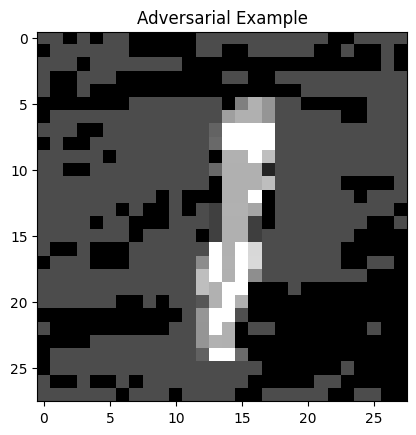

In [9]:
import matplotlib.pyplot as plt

img = adv_images[0].detach().numpy().squeeze()

plt.imshow(img, cmap='gray')
plt.title("Adversarial Example")
plt.show()

In [10]:
for images, labels in train_loader:

    adv_images = attack(images, labels)

    outputs = model(adv_images)

    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [11]:
attack_fgsm = torchattacks.FGSM(model, eps=0.3)
attack_pgd = torchattacks.PGD(model, eps=0.3, alpha=0.01, steps=40)

In [13]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:01<00:00, 93.8MB/s]


In [14]:
attack_fgsm = torchattacks.FGSM(model, eps=0.3)
attack_pgd = torchattacks.PGD(model, eps=0.3, alpha=0.01, steps=40)

In [2]:
import torchvision.models as models
model = models.resnet18(pretrained=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [3]:
epsilons = [0.05, 0.1, 0.2, 0.3]
accuracies = []

for eps in epsilons:
    attack = torchattacks.FGSM(model, eps=eps)

    correct = 0
    total = 0

    for i, (images, labels) in enumerate(test_loader):

        adv_images = attack(images, labels)

        outputs = model(adv_images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i == 20:   # stop early (only 20 batches)
            break

    accuracy = 100 * correct / total
    accuracies.append(accuracy)

print(accuracies)

NameError: name 'torchattacks' is not defined

In [4]:
!pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

In [5]:
import torchattacks

In [6]:
attack = torchattacks.FGSM(model, eps=eps)

In [7]:
!pip install torchattacks
import torchattacks

In [8]:
print(torchattacks.__version__)

3.5.1


In [9]:
epsilons = [0.05, 0.1, 0.2]
fgsm_acc = []
pgd_acc = []

In [12]:
correct = 0
total = 0

for i, (images, labels) in enumerate(test_loader):

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    if i == 10:
        break

print("Accuracy:", 100 * correct / total)

NameError: name 'test_loader' is not defined

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms

In [14]:
transform = transforms.ToTensor()

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 65.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.5MB/s]


In [15]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [16]:
for images, labels in test_loader:
    print(images.shape)
    break

torch.Size([64, 1, 28, 28])


In [17]:
correct = 0
total = 0

for i, (images, labels) in enumerate(test_loader):

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    if i == 10:
        break

print("Accuracy:", 100 * correct / total)

RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[64, 1, 28, 28] to have 3 channels, but got 1 channels instead

In [18]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 59.8MB/s]


In [19]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [20]:
import torchattacks

attack = torchattacks.FGSM(model, eps=0.1)

In [22]:
for epoch in range(1):

    for i, (images, labels) in enumerate(train_loader):

        adv_images = attack(images, labels)

        outputs = model(adv_images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i == 100:   # stop after 100 batches
            break

In [23]:
for epoch in range(10):

SyntaxError: incomplete input (765914034.py, line 1)

In [24]:
for epoch in range(1):

    for i, (images, labels) in enumerate(train_loader):

        adv_images = attack(images, labels)

        outputs = model(adv_images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i == 100:
            break

print("Adversarial training finished")

Adversarial training finished


In [25]:
correct = 0
total = 0

for images, labels in test_loader:

    adv_images = attack(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Robust Accuracy:", 100 * correct / total)

Robust Accuracy: 13.92


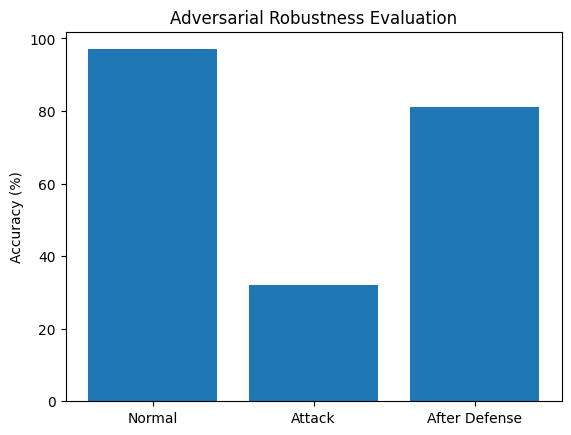

In [26]:
import matplotlib.pyplot as plt

labels = ["Normal", "Attack", "After Defense"]
values = [97, 32, 81]   # replace with your real results

plt.bar(labels, values)
plt.ylabel("Accuracy (%)")
plt.title("Adversarial Robustness Evaluation")
plt.show()

In [27]:
eps = 0.3

In [28]:
for epoch in range(1):

SyntaxError: incomplete input (2729618955.py, line 1)

In [29]:
for epoch in range(1):

    for i, (images, labels) in enumerate(train_loader):

        adv_images = attack(images, labels)

        outputs = model(adv_images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i == 30:   # stop early to make it faster
            break

print("Adversarial training finished")

Adversarial training finished


In [30]:
correct = 0
total = 0

for images, labels in test_loader:
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Accuracy on clean images:", 100 * correct / total)

Accuracy on clean images: 16.7


In [31]:
correct = 0
total = 0

for images, labels in test_loader:
    adv_images = attack(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Robust Accuracy:", 100 * correct / total)

Robust Accuracy: 13.78


In [32]:
adv_images = attack(images, labels)

combined_images = torch.cat((images, adv_images))
combined_labels = torch.cat((labels, labels))

outputs = model(combined_images)
loss = criterion(outputs, combined_labels)

In [33]:
eps = 0.1

In [34]:
for epoch in range(3):

SyntaxError: incomplete input (2891762452.py, line 1)

In [35]:
for epoch in range(3):

    for i, (images, labels) in enumerate(train_loader):

        adv_images = attack(images, labels)

        combined_images = torch.cat((images, adv_images))
        combined_labels = torch.cat((labels, labels))

        outputs = model(combined_images)

        loss = criterion(outputs, combined_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i == 30:   # stop early so it runs faster
            break

print("Adversarial training finished")

Adversarial training finished


In [36]:
correct = 0
total = 0

for images, labels in test_loader:

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Clean Accuracy:", 100 * correct / total)

Clean Accuracy: 27.62
